In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2


# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.plotting_fns import PlottingFns
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.utils import Utils
from stericheight.load_meop import MEOP
from region import Region
from functions import Functions
from OceanDataStore import OceanDataCatalog

pfns = PlottingFns()
fns = Functions()


In [3]:
import gsw
import cartopy
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings
import xesmf as xe
import glob

lon = 145
refz=1000
fname_glorys1 = '../data/GLORYS/glorys_001.nc'
fname_glorys2 = '../data/GLORYS/glorys_002.nc'
fname_sose = '../data/SOSE/adelie3d/Jenny_AdelieSlices'
fname_zhou = '../data/CLIM_3D_forJenny.nc'


In [4]:
elevation_ = GEBCO(coarsen_factor=1).ds.elevation

In [5]:
full_extent = [138, 150,-68,-64]
expanded_extent = [132, 156, -68, -62]

elevation = elevation_.sel(latitude = slice(expanded_extent[2], expanded_extent[3]), longitude = slice(expanded_extent[0],expanded_extent[1]))


In [6]:
# GET COLOURS
cdict = pickle.load(open('cdict.pkl','rb'))


In [7]:
def plot_transect(data,ax,title,vmin,vmax):
    im=data.plot.contourf(ax=ax,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance,add_colorbar=False,levels=40)
    #ax.set_title(title)
    # ax.set_ylim([1000,0])
    ax.set_xlim([-66.5,-64.5])
    ax.invert_yaxis()
    return im


In [8]:
dscli = xr.open_dataset(fname_zhou)
dscli = dscli.squeeze().rename({'lat':'latitude','lon':'longitude','prs':'pressure'}) \
    .swap_dims({'NB_y':'latitude','NB_x':'longitude','NB_LEV':'pressure'})
dscli = fns.crop_to_extent(dscli,full_extent).sel(longitude=lon)
dscli['sigma0'] = gsw.density.sigma0(dscli.sa,dscli.ct)

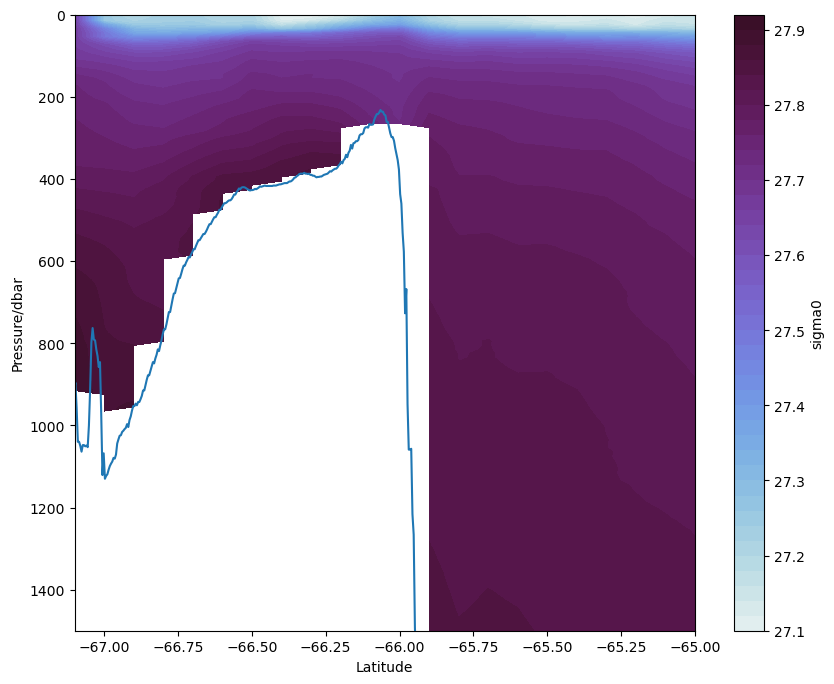

In [9]:
def plot_clim(ax,var,title,cmap):
    im=ax.contourf(dscli.latitude,dscli.pressure,dscli[var],cmap=cmap,levels=40)
    ax.plot(elevation.latitude,-elevation.sel(longitude=lon,method='nearest'))
    ax.set_ylim([0,1500])
    ax.set_xlim([-67.1,-65])
    ax.set_ylabel('Pressure/dbar')
    ax.set_xlabel('Latitude')
    #ax.set_yscale('log')
    ax.yaxis.set_inverted(True)

    cbar = plt.colorbar(im)
    cbar.set_label(title)

fig, ax=plt.subplots(1,1,figsize=(10,8))
plot_clim(ax,'sigma0','sigma0',cmocean.cm.dense)

In [10]:
sose = xr.open_dataset('spatial_average_sose.nc')
en4 = xr.open_dataset('spatial_average_en4.nc')
glorys = xr.open_dataset('spatial_average_glorys.nc')
nemo = xr.open_dataset('spatial_average_nemo.nc')

In [11]:
# use SOSE data to define time and loc bounds
extent = [sose.XC.min(), sose.XC.max(), sose.YC.min(), sose.YC.max()]

In [16]:
sose=xr.open_mfdataset(glob.glob(fname_sose + '/*.nc'))

idx=sose.SALT.load() > 5
sose = sose.where(idx,np.nan)

# use SOSE data to define time and loc bounds
extent = [sose.XC.min(), sose.XC.max(), sose.YC.min(), sose.YC.max()]

sose['pres'] = gsw.conversions.p_from_z(sose.Z,sose.YC.mean())

sose = sose.swap_dims({'Z':'pres'}).drop_vars('Z')

# make monthly
sose=sose.resample({'time':'MS'}).mean()

#sose = sose.sel(pres=slice(0,1000))
sose['asal'] = gsw.SA_from_SP(sose.SALT,sose.pres,sose.XC,sose.YC)
sose['ctemp'] = gsw.CT_from_pt(sose.asal,sose.THETA)
sose['rho'] = gsw.density.rho(sose.asal,sose.ctemp,sose.pres)


In [17]:
en4 = xr.open_dataset('en4_analysis.nc')
en4 = fns.crop_to_extent(en4,extent)

# sort time
en4 = en4.resample({'time':'MS'}).mean()
en4['month'] = en4.time.dt.month
en4['year'] = en4.time.dt.year

en4['pres'] = gsw.conversions.p_from_z(-en4.depth,en4.lat.mean())

en4 = en4.swap_dims({'depth':'pres'}).drop_vars('depth')

#en4 = en4.sel(pres=slice(0,1000))

en4['asal'] = gsw.SA_from_SP(en4.salinity,en4.pres,en4.lon,en4.lat)
en4['ctemp'] = gsw.CT_from_pt(en4.asal,en4.temperature-273.15)
en4['rho'] = gsw.density.rho(en4.asal,en4.ctemp,en4.pres)


In [12]:
# define time bounds covering both datasets
t1 = sose.time[0]
t2 = glorys.time[-1]


In [63]:
ds1 = xr.open_dataset(fname_glorys1)
ds2 = xr.open_dataset(fname_glorys2)
glorys = xr.merge([ds1,ds2])

glorys = fns.crop_to_extent(glorys,extent)
# make monthly
glorys = glorys.resample({'time':'MS'}).mean()
glorys['pres'] = gsw.conversions.p_from_z(-glorys.depth,glorys.latitude.mean())

glorys = glorys.swap_dims({'depth':'pres'}).drop_vars('depth')#.sel(pres=slice(0,1000))

glorys['asal'] = gsw.SA_from_SP(glorys.so,glorys.pres,glorys.longitude,glorys.latitude)
glorys['ctemp'] = gsw.CT_from_pt(glorys.asal,glorys.thetao)
glorys['rho'] = gsw.density.rho(glorys.asal,glorys.ctemp,glorys.pres)



/tmp/ipykernel_633228/3743301605.py:3: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  glorys = xr.merge([ds1,ds2])


In [19]:
# load nemo data
catalog = OceanDataCatalog(catalog_name="noc-model-stac")
nemo = catalog.open_dataset(id='noc-npd-era5/npd-eorca12-era5v1/gn/T1m_4d',variable_names=['thetao_con','so_abs'])

# prepare nemo
# crop to region
lats = nemo.nav_lat.load()
lons = nemo.nav_lon.load()
mask = (lats >= extent[2]) & (lats <= extent[3]) & (lons >= extent[0]) & (lons <= extent[1])
# crop to area and coarsen
nemo = nemo.where(mask,drop=True).coarsen({'y':6,'x':6},boundary='trim').mean()

# make monthly
nemo = nemo.rename({'time_counter':'time'}).resample({'time':'MS'}).mean()

nemo['pres'] = gsw.conversions.p_from_z(-nemo.deptht,nemo.nav_lat.mean())

nemo = nemo.swap_dims({'deptht':'pres'}).drop_vars('deptht')#.sel(pres=slice(0,1000))

nemo['rho'] = gsw.density.rho(nemo.so_abs,nemo.thetao_con,nemo.pres)



  2026-06-01T08:58:09.109728Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /root/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



In [13]:
t1 = sose.time[0]
t2 = glorys.time[-1]

In [14]:
# assign colours for easy plotting
colors = {'SHA': 'rebeccapurple',
          'GPHA': 'lightsteelblue',
          'GLORYS': 'lightseagreen',
          'NEMO' : 'palevioletred',
          'SOSE' : 'orange',
          'EN4': 'dodgerblue',
          'MASS': 'grey'}


In [50]:
nemo

<xarray.Dataset> Size: 961MB
Dimensions:     (time: 594, pres: 75, y: 29, x: 31)
Coordinates:
  * time        (time) datetime64[ns] 5kB 1976-01-01 1976-02-01 ... 2025-06-01
  * pres        (pres) float64 600B 0.5108 1.571 2.694 ... 5.833e+03 6.044e+03
  * y           (y) float64 232B 885.5 891.5 897.5 ... 1.048e+03 1.054e+03
  * x           (x) float64 248B 772.5 778.5 784.5 790.5 ... 940.5 946.5 952.5
    nav_lat     (y, x) float64 7kB -68.88 -68.88 -68.88 ... -63.25 -63.25 -63.25
    nav_lon     (y, x) float64 7kB 137.4 137.9 138.4 138.9 ... 151.4 151.9 152.4
Data variables:
    thetao_con  (time, pres, y, x) float32 160MB dask.array<chunksize=(1, 25, 29, 31), meta=np.ndarray>
    so_abs      (time, pres, y, x) float32 160MB dask.array<chunksize=(1, 25, 29, 31), meta=np.ndarray>
    rho         (time, pres, y, x) float64 320MB dask.array<chunksize=(1, 25, 29, 31), meta=np.ndarray>
    sigma0      (time, pres, y, x) float64 320MB dask.array<chunksize=(1, 25, 29, 31), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA12_1m_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Dec-03 20:51:31 GMT
    uuid:         a8ac37d1-a8ff-4925-b791-f0d6111ec8e1

In [64]:
glorys['sigma0'] = gsw.density.sigma0(glorys.asal,glorys.ctemp)
gloryslon = glorys.sel(longitude=lon,method='nearest').mean('time')


In [ ]:
sose['sigma0'] = gsw.density.sigma0(sose.asal,sose.ctemp)
nemo['sigma0'] = gsw.density.sigma0(nemo.so_abs,nemo.thetao_con)
en4['sigma0'] = gsw.density.sigma0(en4.asal,en4.ctemp)


soselon = sose.sel(XC=lon,method='nearest').mean('time')
en4lon = en4.sel(lon=lon,method='nearest').mean('time')
nemolon = nemo.where((nemo.nav_lon >= lon-0.2) & (nemo.nav_lon <= lon+0.2),drop=True).squeeze().mean('time')

In [57]:
nemolon.sigma0.load()

<xarray.DataArray 'sigma0' (pres: 75, y: 29)> Size: 17kB
array([[        nan,         nan,         nan, ..., 27.26637584,
        27.25514383, 27.24365809],
       [        nan,         nan,         nan, ..., 27.26883249,
        27.2573028 , 27.24543245],
       [        nan,         nan,         nan, ..., 27.27033316,
        27.25866715, 27.24660904],
       ...,
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]], shape=(75, 29))
Coordinates:
  * pres     (pres) float64 600B 0.5108 1.571 2.694 ... 5.833e+03 6.044e+03
  * y        (y) float64 232B 885.5 891.5 897.5 ... 1.048e+03 1.054e+03
    nav_lat  (y) float64 232B -68.88 -68.7 -68.52 ... -63.69 -63.47 -63.25
    nav_lon  (y) float64 232B 144.9 144.9 144.9 144.9 ... 144.9 144.9 144.9
    x        float64 8B 862.5
Attributes:
    standard_name:       sea_water_absolute_salinity
    long_name:           sea_water_absolute_salinity
    units:               g/kg
    online_operation:    average
    interval_operation:  1 month
    interval_write:      1 month
    cell_methods:        time: mean

In [58]:
nemolon.sigma0.to_netcdf('nemolon_sigma0.nc')

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3699: SerializationWarning: saving variable y with floating point data as an integer dtype without any _FillValue to use for NaNs
  exec(code_obj, self.user_global_ns, self.user_ns)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3699: SerializationWarning: saving variable x with floating point data as an integer dtype without any _FillValue to use for NaNs
  exec(code_obj, self.user_global_ns, self.user_ns)


In [26]:
soselon.to_netcdf('soselon.nc')
gloryslon.to_netcdf('gloryslon.nc')
en4lon.to_netcdf('en4lon.nc')

KeyboardInterrupt: 

In [87]:
nemo.so_abs.load()

<xarray.DataArray 'so_abs' (time: 594, pres: 75, y: 29, x: 31)> Size: 160MB
array([[[[      nan,       nan,       nan, ...,       nan,       nan,
                nan],
         [      nan,       nan,       nan, ..., 32.758972, 33.071224,
                nan],
         [      nan,       nan,       nan, ..., 32.47226 , 32.862408,
                nan],
         ...,
         [34.116615, 34.115566, 34.1185  , ..., 34.076077, 34.05032 ,
          34.051926],
         [34.124615, 34.121174, 34.11773 , ..., 34.055065, 34.04489 ,
          34.058594],
         [34.098648, 34.0997  , 34.09637 , ..., 34.072475, 34.092117,
          34.11702 ]],

        [[      nan,       nan,       nan, ...,       nan,       nan,
                nan],
         [      nan,       nan,       nan, ..., 32.898785, 33.13649 ,
                nan],
         [      nan,       nan,       nan, ..., 32.6292  , 32.984505,
                nan],
...
         [      nan,       nan,       nan, ...,       nan,       nan,
                nan],
         [      nan,       nan,       nan, ...,       nan,       nan,
                nan],
         [      nan,       nan,       nan, ...,       nan,       nan,
                nan]],

        [[      nan,       nan,       nan, ...,       nan,       nan,
                nan],
         [      nan,       nan,       nan, ...,       nan,       nan,
                nan],
         [      nan,       nan,       nan, ...,       nan,       nan,
                nan],
         ...,
         [      nan,       nan,       nan, ...,       nan,       nan,
                nan],
         [      nan,       nan,       nan, ...,       nan,       nan,
                nan],
         [      nan,       nan,       nan, ...,       nan,       nan,
                nan]]]], shape=(594, 75, 29, 31), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 5kB 1976-01-01 1976-02-01 ... 2025-06-01
  * pres     (pres) float64 600B 0.5108 1.571 2.694 ... 5.833e+03 6.044e+03
  * y        (y) float64 232B 885.5 891.5 897.5 ... 1.048e+03 1.054e+03
  * x        (x) float64 248B 772.5 778.5 784.5 790.5 ... 940.5 946.5 952.5
    nav_lat  (y, x) float64 7kB -68.88 -68.88 -68.88 ... -63.25 -63.25 -63.25
    nav_lon  (y, x) float64 7kB 137.4 137.9 138.4 138.9 ... 151.4 151.9 152.4
Attributes:
    standard_name:       sea_water_absolute_salinity
    long_name:           sea_water_absolute_salinity
    units:               g/kg
    online_operation:    average
    interval_operation:  1 month
    interval_write:      1 month
    cell_methods:        time: mean

In [88]:
nemo.thetao_con.load()

<xarray.DataArray 'thetao_con' (time: 594, pres: 75, y: 29, x: 31)> Size: 160MB
array([[[[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ..., -0.41765893,
          -0.04947575,         nan],
         [        nan,         nan,         nan, ..., -1.2579973 ,
          -0.7692889 ,         nan],
         ...,
         [ 2.1907134 ,  2.230513  ,  2.247726  , ...,  2.078773  ,
           1.9309129 ,  1.8851492 ],
         [ 2.052965  ,  2.0820284 ,  2.125802  , ...,  2.032338  ,
           1.9418119 ,  1.9415659 ],
         [ 2.0659573 ,  2.0964098 ,  2.1406727 , ...,  2.0422478 ,
           1.9634225 ,  1.8923429 ]],

        [[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ..., -0.33297107,
          -0.04888938,         nan],
         [        nan,         nan,         nan, ..., -1.114555  ,
          -0.68791264,         nan],
...
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]],

        [[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         ...,
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]]]],
      shape=(594, 75, 29, 31), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 5kB 1976-01-01 1976-02-01 ... 2025-06-01
  * pres     (pres) float64 600B 0.5108 1.571 2.694 ... 5.833e+03 6.044e+03
  * y        (y) float64 232B 885.5 891.5 897.5 ... 1.048e+03 1.054e+03
  * x        (x) float64 248B 772.5 778.5 784.5 790.5 ... 940.5 946.5 952.5
    nav_lat  (y, x) float64 7kB -68.88 -68.88 -68.88 ... -63.25 -63.25 -63.25
    nav_lon  (y, x) float64 7kB 137.4 137.9 138.4 138.9 ... 151.4 151.9 152.4
Attributes:
    standard_name:       sea_water_conservative_temperature
    long_name:           sea_water_conservative_temperature
    units:               degC
    online_operation:    average
    interval_operation:  1 month
    interval_write:      1 month
    cell_methods:        time: mean

In [60]:
def plot_clim(ax,da,lat,pres,title,cmap):
    im=ax.contourf(lat,pres,da,cmap=cmap,levels=40,vmin=27.2,vmax=27.9)
    ax.plot(elevation.latitude,-elevation.sel(longitude=lon,method='nearest'))
    ax.set_ylim([0,1500])
    ax.set_xlim([-67.1,-65])
    ax.set_ylabel('Pressure/dbar')
    ax.set_xlabel('Latitude')
    #ax.set_yscale('log')
    ax.yaxis.set_inverted(True)

    cbar = plt.colorbar(im)
    cbar.set_label(title)


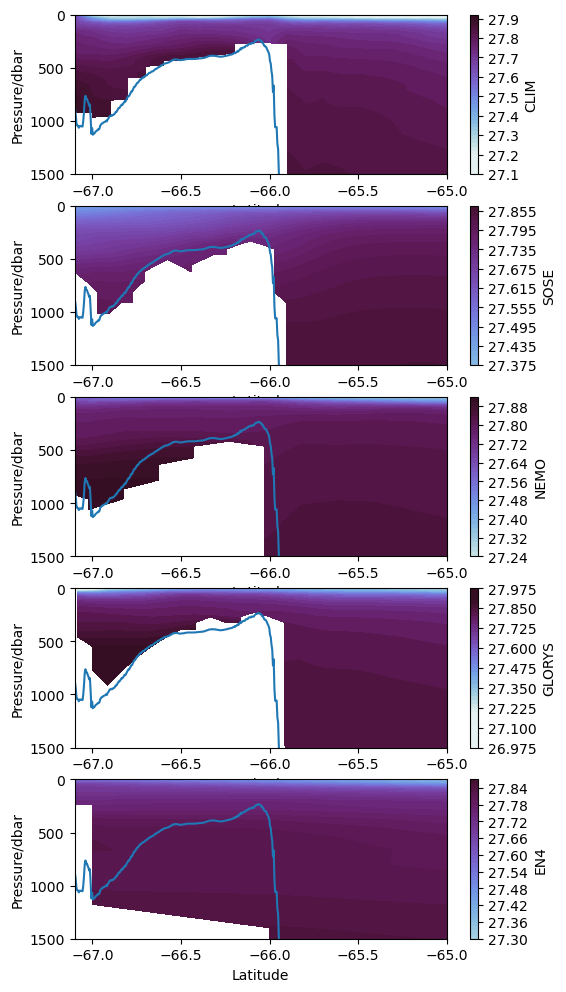

In [ ]:
fig,ax = plt.subplots(5,1,figsize=(6,12))
plot_clim(ax[0],dscli.sigma0,dscli.latitude,dscli.pressure,'CLIM',cmocean.cm.dense)
plot_clim(ax[1],soselon.sigma0,soselon.YC,soselon.pres,'SOSE',cmocean.cm.dense)
plot_clim(ax[2],nemolon.sigma0,nemolon.nav_lat,nemolon.pres,'NEMO',cmocean.cm.dense)
plot_clim(ax[3],gloryslon.sigma0,gloryslon.latitude,gloryslon.pres,'GLORYS',cmocean.cm.dense)
plot_clim(ax[4],en4lon.sigma0,en4lon.lat,en4lon.pres,'EN4',cmocean.cm.dense)


<xarray.Dataset> Size: 54kB
Dimensions:     (pres: 75, nav_lat: 29)
Coordinates:
  * pres        (pres) float64 600B 0.5108 1.571 2.694 ... 5.833e+03 6.044e+03
  * nav_lat     (nav_lat) float64 232B -68.88 -68.7 -68.52 ... -63.47 -63.25
    nav_lon     (nav_lat) float64 232B 144.9 144.9 144.9 ... 144.9 144.9 144.9
    y           (nav_lat) float64 232B 885.5 891.5 897.5 ... 1.048e+03 1.054e+03
    x           float64 8B 862.5
Data variables:
    thetao_con  (pres, nav_lat) float32 9kB dask.array<chunksize=(25, 29), meta=np.ndarray>
    so_abs      (pres, nav_lat) float32 9kB dask.array<chunksize=(25, 29), meta=np.ndarray>
    rho         (pres, nav_lat) float64 17kB dask.array<chunksize=(25, 29), meta=np.ndarray>
    sigma0      (pres, nav_lat) float64 17kB nan nan nan nan ... nan nan nan nan
Attributes:
    name:         OUTPUT/eORCA12_1m_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Dec-03 20:51:31 GMT
    uuid:         a8ac37d1-a8ff-4925-b791-f0d6111ec8e1

In [71]:
sosecli = soselon.interp({'YC':dscli.latitude,'pres':dscli.pressure})
nemocli = nemolon.swap_dims({'y':'nav_lat'}).interp({'nav_lat':dscli.latitude,'pres':dscli.pressure})
gloryscli = gloryslon.interp({'latitude':dscli.latitude,'pres':dscli.pressure})

In [75]:
def plot_clim(ax,da,lat,pres,title,cmap):
    im=ax.contourf(lat,pres,da,cmap=cmap,levels=40,vmin=-0.4,vmax=0.4)
    ax.plot(elevation.latitude,-elevation.sel(longitude=lon,method='nearest'))
    ax.set_ylim([0,1500])
    ax.set_xlim([-67.1,-65])
    ax.set_ylabel('Pressure/dbar')
    ax.set_xlabel('Latitude')
    #ax.set_yscale('log')
    ax.yaxis.set_inverted(True)

    cbar = plt.colorbar(im)
    cbar.set_label(title)


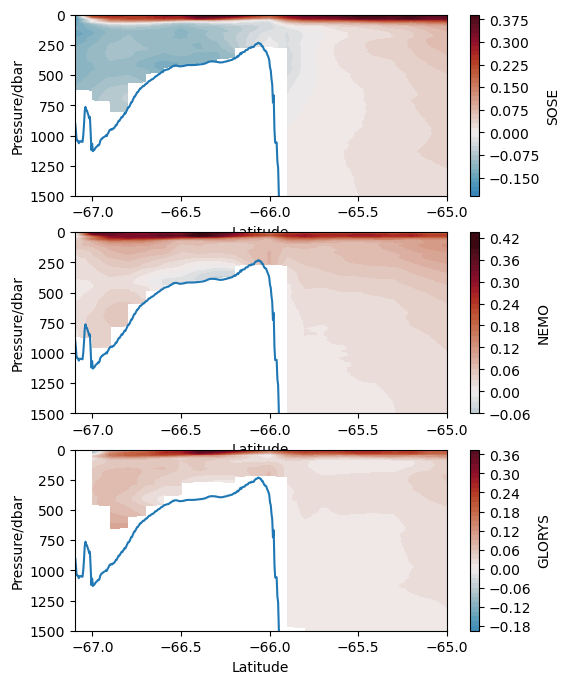

In [76]:
fig,ax = plt.subplots(3,1,figsize=(6,8))
plot_clim(ax[0],sosecli.sigma0-dscli.sigma0,dscli.latitude,dscli.pressure,'SOSE',cmocean.cm.balance)
plot_clim(ax[1],nemocli.sigma0-dscli.sigma0,dscli.latitude,dscli.pressure,'NEMO',cmocean.cm.balance)
plot_clim(ax[2],gloryscli.sigma0-dscli.sigma0,dscli.latitude,dscli.pressure,'GLORYS',cmocean.cm.balance)



In [84]:
def plot_clim(ax,da,lat,pres,title,cmap):
    im=ax.contourf(lat,pres,da,cmap=cmap,levels=40,vmin=27.6,vmax=27.8)
    ax.plot(elevation.latitude,-elevation.sel(longitude=lon,method='nearest'))
    ax.set_ylim([150,550])
    ax.set_xlim([-66.3,-65.8])
    ax.set_ylabel('Pressure/dbar')
    ax.set_xlabel('Latitude')
    #ax.set_yscale('log')
    ax.yaxis.set_inverted(True)

    cbar = plt.colorbar(im)
    cbar.set_label(title)


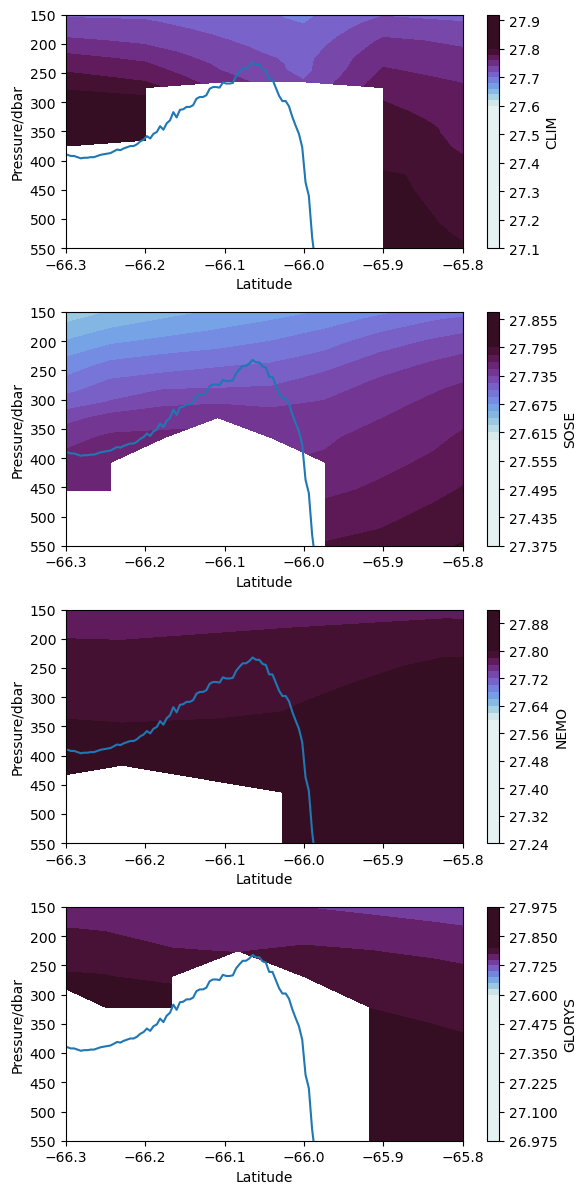

In [85]:
fig,ax = plt.subplots(4,1,figsize=(6,12))
plot_clim(ax[0],dscli.sigma0,dscli.latitude,dscli.pressure,'CLIM',cmocean.cm.dense)
plot_clim(ax[1],soselon.sigma0,soselon.YC,soselon.pres,'SOSE',cmocean.cm.dense)
plot_clim(ax[2],nemolon.sigma0,nemolon.nav_lat,nemolon.pres,'NEMO',cmocean.cm.dense)
plot_clim(ax[3],gloryslon.sigma0,gloryslon.latitude,gloryslon.pres,'GLORYS',cmocean.cm.dense)

plt.tight_layout()
